In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import decimate

df = pd.read_csv("/home/razzannr/Documents/GitHub/consciousness_app_eeg/muse_af7_sample_test_gui_02.csv")
df.head()

,relative_time_sec,lsl_timestamp,local_timestamp_perf_counter,AF7
0,0.000014,1.779084e+09,4464.633615,20.996094
1,0.015630,1.779084e+09,4464.649232,22.460938
2,0.015752,1.779084e+09,4464.649353,20.507812
3,0.015764,1.779084e+09,4464.649365,23.925781
4,0.015777,1.779084e+09,4464.649379,20.996094


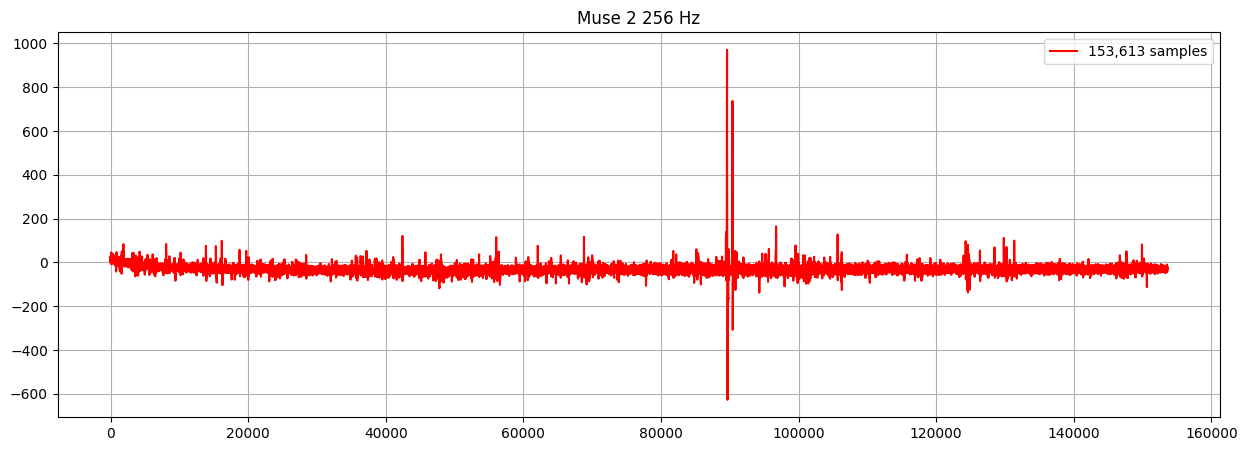

In [2]:
af7 = df["AF7"]

x = np.arange(0, len(af7))
y = af7
plt.figure(figsize=(15,5))
plt.plot(x,y, label=f"{len(y):,} samples", color="red")
plt.title("Muse 2 256 Hz")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

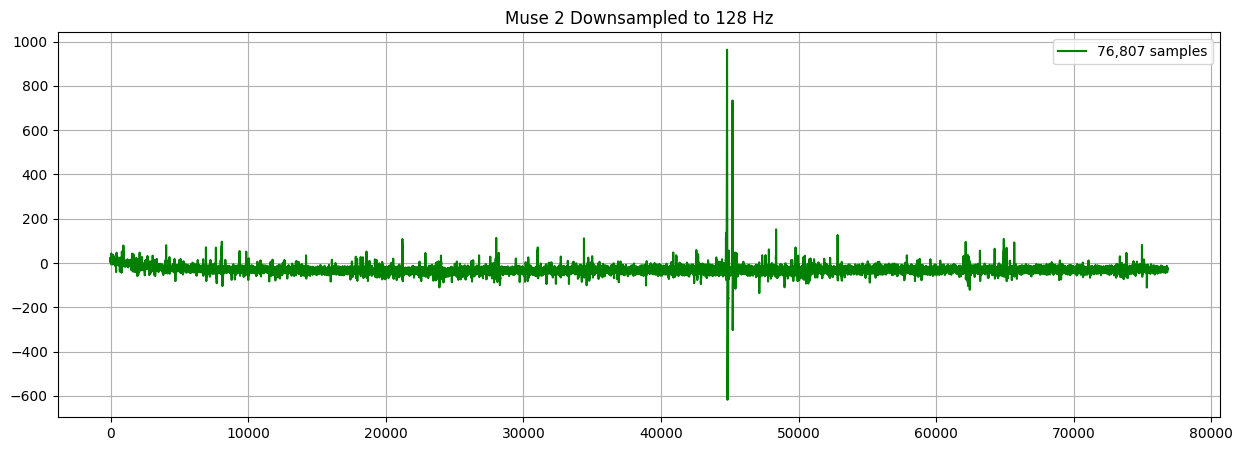

In [3]:
down = decimate(af7, 2, zero_phase=True)

downX = np.arange(0, len(down))
plt.figure(figsize=(15,5))
plt.plot(downX, down, label=f"{len(down):,} samples", color="green")
plt.title("Muse 2 Downsampled to 128 Hz")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

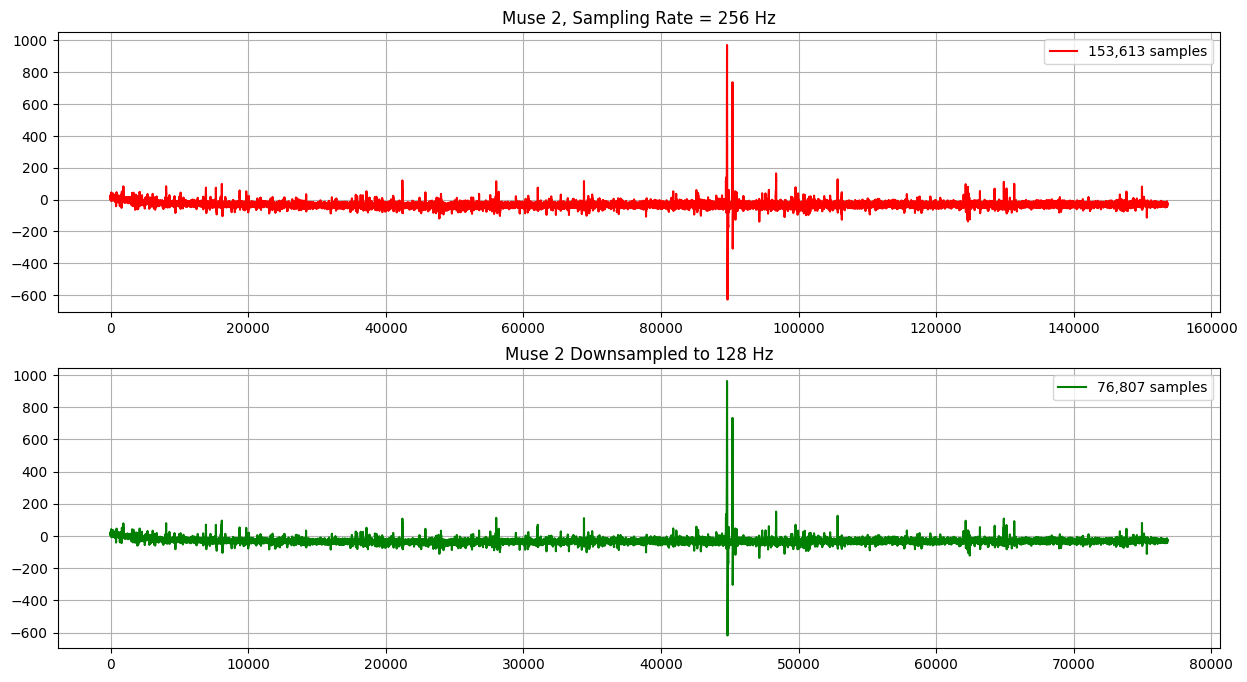

In [4]:
plt.figure(figsize=(15,8))

plt.subplot(2,1,1)
plt.plot(x,y, label=f"{len(y):,} samples", color="red")
plt.title("Muse 2, Sampling Rate = 256 Hz")
plt.legend(loc="upper right")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(downX, down, label=f"{len(down):,} samples", color="green")
plt.title("Muse 2 Downsampled to 128 Hz")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

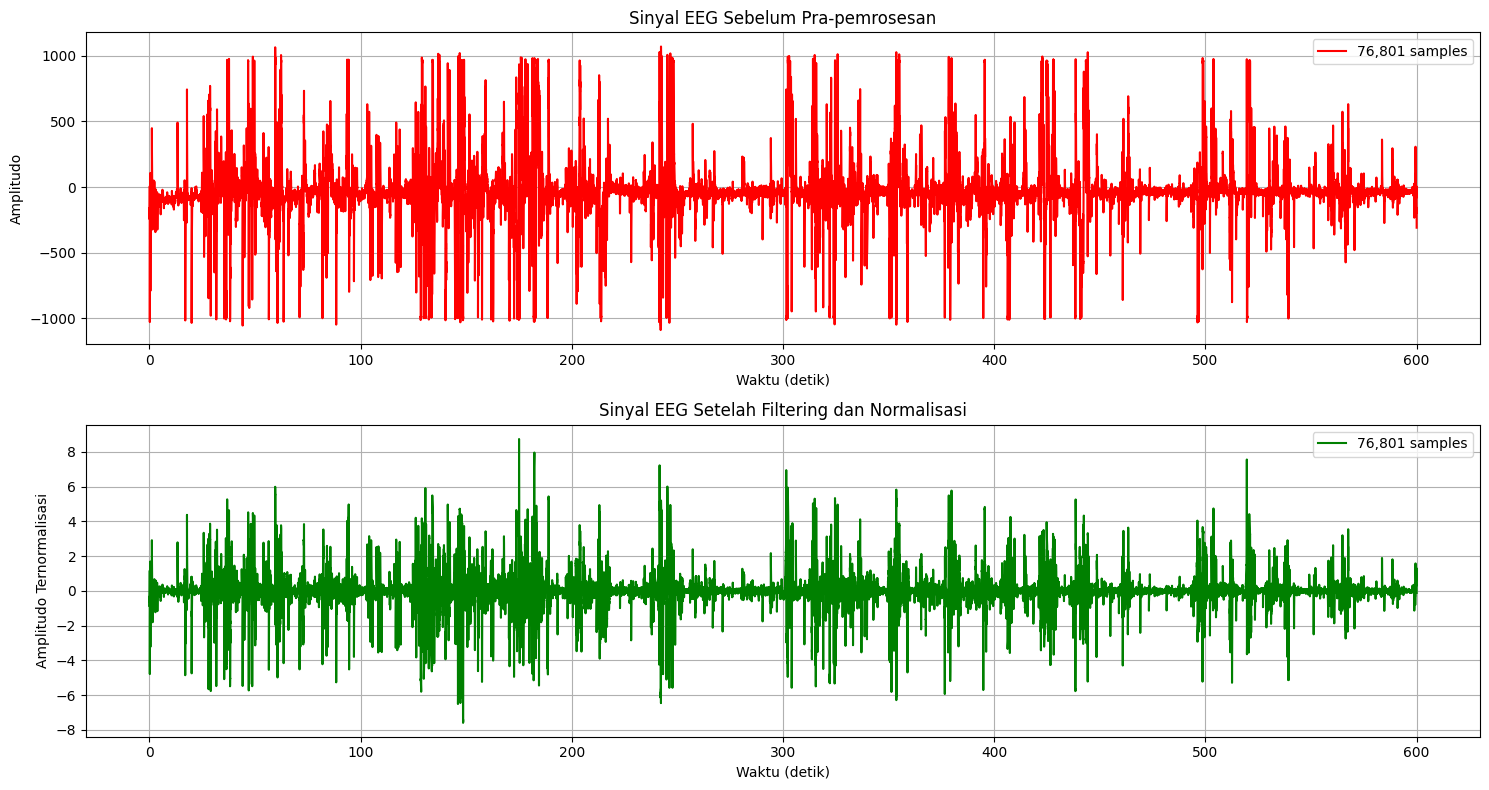

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, iirnotch, sosfiltfilt, tf2sos


def apply_eeg_filter(signal, fs=128):
    signal = np.asarray(signal, dtype=float).ravel()
    signal = signal - np.mean(signal)

    sos_band = butter(
        N=4,
        Wn=[0.5, 45.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered = sosfiltfilt(sos_band, signal)

    b_notch, a_notch = iirnotch(
        w0=50.0,
        Q=30.0,
        fs=fs
    )

    sos_notch = tf2sos(b_notch, a_notch)
    filtered = sosfiltfilt(sos_notch, filtered)

    return filtered


def normalize_window(signal):
    signal = np.asarray(signal, dtype=float).ravel()
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    return signal


csv_path = "/home/razzannr/Documents/GitHub/consciousness_app_eeg/fadlan_akui.csv"
fs = 128

df = pd.read_csv(csv_path)

signal = df["AF7"].dropna().to_numpy(dtype=float)
downsampled = decimate(signal, 2, zero_phase=True)

filtered = apply_eeg_filter(downsampled, fs=fs)
preprocessed = normalize_window(filtered)

time = np.arange(len(downsampled)) / fs

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(time, downsampled, color="red", label=f"{len(downsampled):,} samples")
plt.title("Sinyal EEG Sebelum Pra-pemrosesan")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.legend(loc="upper right")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time, preprocessed, color="green", label=f"{len(preprocessed):,} samples")
plt.title("Sinyal EEG Setelah Filtering dan Normalisasi")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo Ternormalisasi")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
plt.show()

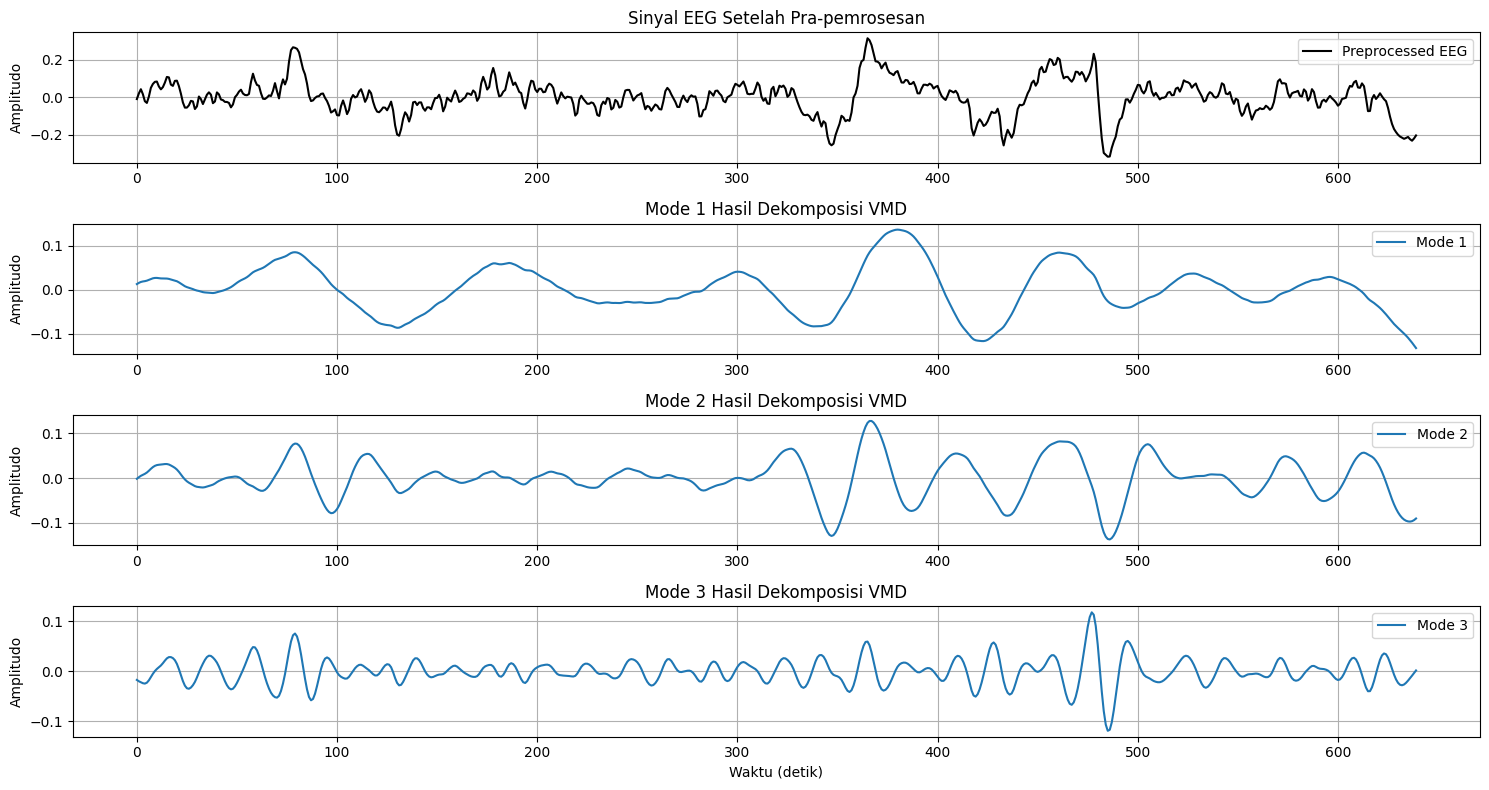

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD


def apply_vmd(signal, K=3):
    signal = np.asarray(signal, dtype=float).ravel()

    VMD_ALPHA = 100
    VMD_TAU = 0
    VMD_DC = 0
    VMD_INIT = 1
    VMD_TOL = 1e-7

    modes, _, _ = VMD(
        signal,
        VMD_ALPHA,
        VMD_TAU,
        K,
        VMD_DC,
        VMD_INIT,
        VMD_TOL
    )

    return modes


K = 3
modes = apply_vmd(preprocessed, K=K)

time = np.arange(640)
preprocessed = preprocessed[1000:1640]

plt.figure(figsize=(15, 8))

plt.subplot(4, 1, 1)
plt.plot(time, preprocessed, color="black", label="Preprocessed EEG")
plt.title("Sinyal EEG Setelah Pra-pemrosesan")
plt.ylabel("Amplitudo")
plt.legend(loc="upper right")
plt.grid(True)

for i in range(K):
    plt.subplot(4, 1, i + 2)
    plt.plot(time, modes[i][1000:1640], label=f"Mode {i + 1}")
    plt.title(f"Mode {i + 1} Hasil Dekomposisi VMD")
    plt.ylabel("Amplitudo")
    plt.legend(loc="upper right")
    plt.grid(True)

plt.xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
from pathlib import Path

folder = Path("/home/razzannr/Documents/GitHub/consciousness_app_eeg/Tidak_Sadar")

files = sorted(folder.glob("TidakSadar_RSSA_*.csv"))

dfs = []

for file in files:
    df = pd.read_csv(file)
    df["source_file"] = file.name
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

combined.to_csv("TidakSadar_RSSA_combined.csv", index=False)

print("File yang digabung:")
for file in files:
    print(file.name)

print("Berhasil dibuat: TidakSadar_RSSA_combined.csv")
print("Jumlah sampel:", len(combined))

File yang digabung:
TidakSadar_RSSA_01.csv
TidakSadar_RSSA_02.csv
TidakSadar_RSSA_03.csv
TidakSadar_RSSA_04.csv
TidakSadar_RSSA_05.csv
Berhasil dibuat: TidakSadar_RSSA_combined.csv
Jumlah sampel: 153592
